# Autoencoder Anomaly Detection

In [1]:
TrainedLabels = [0]
BlacklistLabels = [i for i in range(0, 10) if i not in TrainedLabels]


In [2]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
# from https://www.kaggle.com/code/hojjatk/read-mnist-dataset
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self, blacklist_labels=None):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        
        if blacklist_labels is not None:
            # Filter out blacklisted labels
            train_mask = np.array([label not in blacklist_labels for label in y_train])
            # test_mask = np.array([label not in blacklist_labels for label in y_test])
            
            x_train = [x for x, mask in zip(x_train, train_mask) if mask]
            y_train = [y for y, mask in zip(y_train, train_mask) if mask]
            # x_test = [x for x, mask in zip(x_test, test_mask) if mask]
            # y_test = [y for y, mask in zip(y_test, test_mask) if mask]
        
        return (x_train, y_train),(x_test, y_test)  

## Autoencoder Model

In [3]:
import torch
from torch import nn

class AutoEncoder(nn.Module):
	def __init__(self):
		super(AutoEncoder, self).__init__()
		self.encoder = nn.Sequential(
			nn.Linear(28 * 28, 128),
			nn.ReLU(),
			nn.Linear(128, 64),
			nn.ReLU(),
			nn.Linear(64, 36),
			nn.ReLU(),
			nn.Linear(36, 18),
			nn.ReLU(),
			nn.Linear(18, 9),
		)
		self.decoder = nn.Sequential(
			nn.Linear(9, 18),
			nn.ReLU(),
			nn.Linear(18, 36),
			nn.ReLU(),
			nn.Linear(36, 64),
			nn.ReLU(),
			nn.Linear(64, 128),
			nn.ReLU(),
			nn.Linear(128, 28 * 28),
			nn.Sigmoid()
		)
	def forward(self, x):
		encoded = self.encoder(x)
		decoded = self.decoder(encoded)
		return decoded

## Loading Data

In [4]:
dataLoader = MnistDataloader(
	training_images_filepath=join('..', 'inputs', 'mnist', 'train-images.idx3-ubyte'),
	training_labels_filepath=join('..', 'inputs', 'mnist', 'train-labels.idx1-ubyte'),
	test_images_filepath=join('..', 'inputs', 'mnist', 't10k-images.idx3-ubyte'),
	test_labels_filepath=join('..', 'inputs', 'mnist', 't10k-labels.idx1-ubyte')
)
(x_train, y_train),(x_test, y_test) = dataLoader.load_data(blacklist_labels=BlacklistLabels)
print('Training set: {} samples'.format(len(x_train)))
print('Test set: {} samples'.format(len(x_test)))

Training set: 5923 samples
Test set: 10000 samples


## Prepare Data For Autoencoder

In [5]:
x_train = np.array(x_train, dtype=np.float32) / 255.0
x_train = x_train.reshape(-1, 28 * 28)

x_test = np.array(x_test, dtype=np.float32) / 255.0
x_test = x_test.reshape(-1, 28 * 28)

y_test = np.array(y_test, dtype=np.int64)


## Training

Using CUDA device: NVIDIA GeForce RTX 5080
Epoch [1/30], Batch Size: 256, Loss: 0.2059
Epoch [2/30], Batch Size: 256, Loss: 0.0894
Epoch [3/30], Batch Size: 256, Loss: 0.0652
Epoch [4/30], Batch Size: 256, Loss: 0.0634
Epoch [5/30], Batch Size: 256, Loss: 0.0624
Epoch [6/30], Batch Size: 256, Loss: 0.0614
Epoch [7/30], Batch Size: 256, Loss: 0.0610
Epoch [8/30], Batch Size: 256, Loss: 0.0604
Epoch [9/30], Batch Size: 256, Loss: 0.0576
Epoch [10/30], Batch Size: 256, Loss: 0.0542
Epoch [11/30], Batch Size: 256, Loss: 0.0521
Epoch [12/30], Batch Size: 256, Loss: 0.0509
Epoch [13/30], Batch Size: 256, Loss: 0.0495
Epoch [14/30], Batch Size: 256, Loss: 0.0484
Epoch [15/30], Batch Size: 256, Loss: 0.0472
Epoch [16/30], Batch Size: 256, Loss: 0.0459
Epoch [17/30], Batch Size: 256, Loss: 0.0446
Epoch [18/30], Batch Size: 256, Loss: 0.0433
Epoch [19/30], Batch Size: 256, Loss: 0.0425
Epoch [20/30], Batch Size: 256, Loss: 0.0412
Epoch [21/30], Batch Size: 256, Loss: 0.0404
Epoch [22/30], Batch 

Text(0.5, 1.0, 'Training Loss over Iterations')

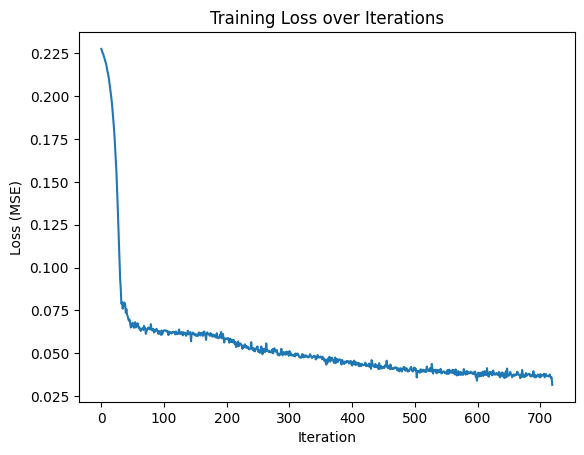

In [6]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

epochs = 30
batch_size = 256

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
	print('Using CUDA device:', torch.cuda.get_device_name(0))
else:
	print('Using device:', device)

model = AutoEncoder().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

# * Convert original MNIST into batched TensorDataset and DataLoader for better performance
train_tensor = torch.from_numpy(x_train).float()
train_dataset = TensorDataset(train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

losses = []

for epoch in range(epochs):
	epoch_losses = []
	for (batch_images,) in train_loader:
		batch_images = batch_images.to(device)
		output = model(batch_images)
		loss = loss_fn(output, batch_images)
		optimizer.zero_grad()
		loss.backward()
		optimizer.step()

		epoch_losses.append(loss.item())

	losses.extend(epoch_losses)
	print('Epoch [{}/{}], Batch Size: {}, Loss: {:.4f}'.format(
		epoch + 1, epochs, batch_size, np.mean(epoch_losses)
	))

plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Iterations')


## Anomaly Detection

In [7]:
test_data_tensor = torch.from_numpy(x_test).float().to(device)
test_label_tensor = torch.from_numpy(y_test).long().to(device)
with torch.no_grad():
	reconstructed = model(test_data_tensor)
	print('Reconstruction completed.')

# Calculate reconstruction errors (MSE per sample)
mse_values = torch.mean((test_data_tensor - reconstructed) ** 2, dim=1).cpu().numpy()

# Create binary labels: 0 for normal (TrainedLabels), 1 for anomaly (BlacklistLabels)
y_test_binary = np.array([0 if label in TrainedLabels else 1 for label in y_test])

print(f'Normal samples (label 0): {np.sum(y_test_binary == 0)}')
print(f'Anomaly samples (other digits): {np.sum(y_test_binary == 1)}')

Reconstruction completed.
Normal samples (label 0): 980
Anomaly samples (other digits): 9020


## AUROC Curve

This curve is plotted with respect to the training samples provided by MNIST.

AUROC Score: 0.9596


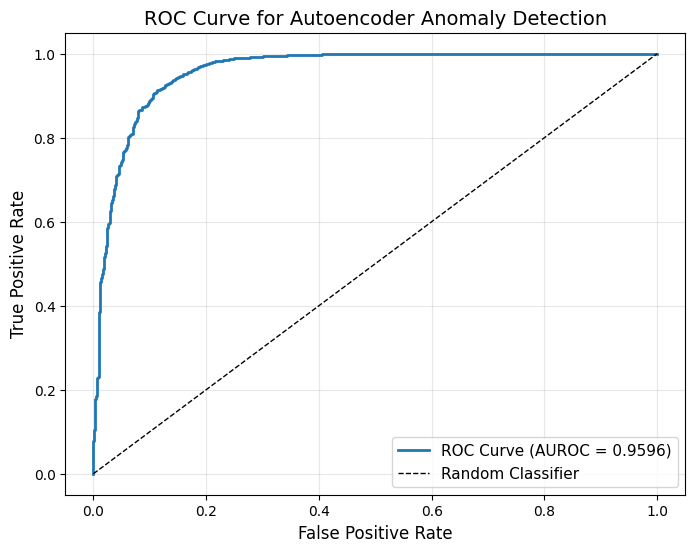

In [8]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, precision_recall_curve
from scipy.optimize import fminbound

# Calculate AUROC
auroc = roc_auc_score(y_test_binary, mse_values)
print(f'AUROC Score: {auroc:.4f}')

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test_binary, mse_values)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUROC = {auroc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve for Autoencoder Anomaly Detection', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()


=== Optimal Threshold Result ===
Optimal Threshold: 0.046909
F1 Score: 0.9811
Precision: 0.9733
Recall: 0.9891

Confusion Matrix:
TN: 735	 FP: 245
FN: 98	 TP: 8922


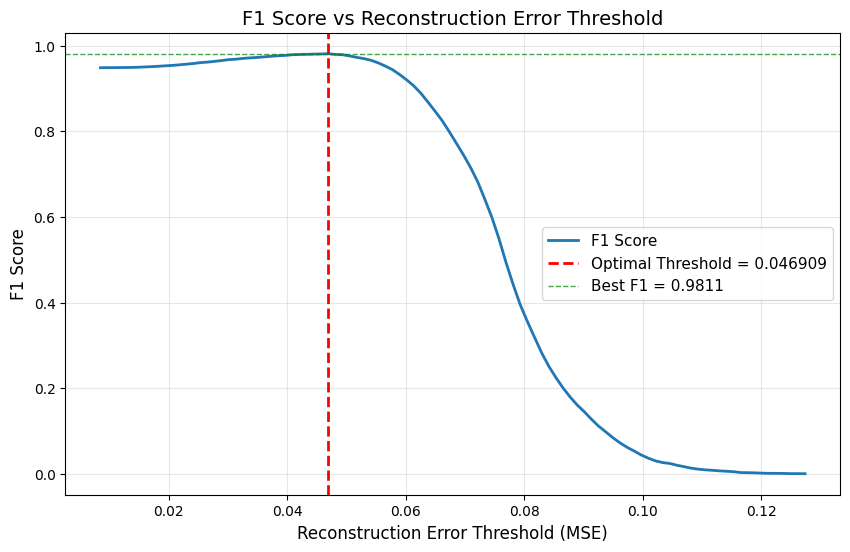

In [9]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Find optimal threshold for F1 score
best_f1 = 0
best_threshold = 0
f1_scores = []
thresholds_f1 = np.linspace(mse_values.min(), mse_values.max(), 100)

for threshold in thresholds_f1:
    y_pred = (mse_values >= threshold).astype(int)
    f1 = f1_score(y_test_binary, y_pred, zero_division=0)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

y_pred_optimal = (mse_values >= best_threshold).astype(int)
precision = precision_score(y_test_binary, y_pred_optimal, zero_division=0)
recall = recall_score(y_test_binary, y_pred_optimal, zero_division=0)
cm = confusion_matrix(y_test_binary, y_pred_optimal)

print(f'\n=== Optimal Threshold Result ===')
print(f'Optimal Threshold: {best_threshold:.6f}')
print(f'F1 Score: {best_f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'\nConfusion Matrix:')
print(f'TN: {cm[0, 0]}\t FP: {cm[0, 1]}')
print(f'FN: {cm[1, 0]}\t TP: {cm[1, 1]}')

plt.figure(figsize=(10, 6))
plt.plot(thresholds_f1, f1_scores, linewidth=2, label='F1 Score')
plt.axvline(best_threshold, color='r', linestyle='--', linewidth=2, label=f'Optimal Threshold = {best_threshold:.6f}')
plt.axhline(best_f1, color='g', linestyle='--', linewidth=1, alpha=0.7, label=f'Best F1 = {best_f1:.4f}')
plt.xlabel('Reconstruction Error Threshold (MSE)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Score vs Reconstruction Error Threshold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Reconstruction Test

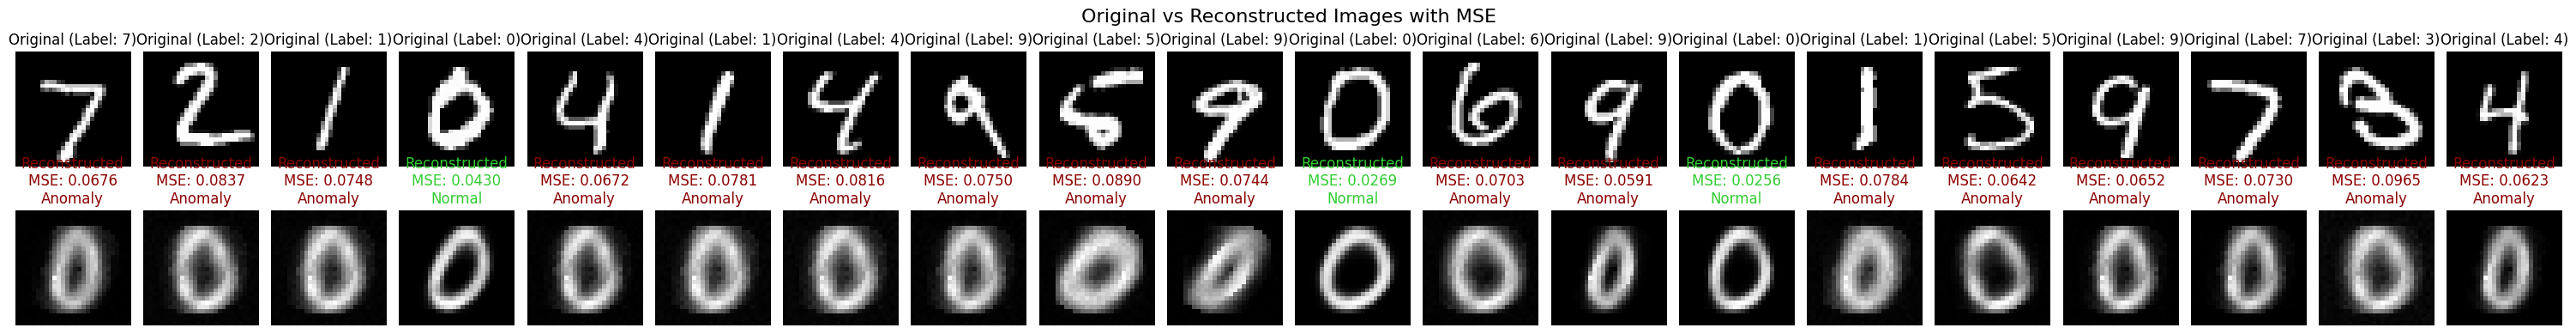

In [ ]:
# show first 20 test samples with their reconstruction and MSE
num_samples_to_show = 20
plt.figure(figsize=(35, 5))
for i in range(num_samples_to_show):
	original_image = x_test[i].reshape(28, 28)
	reconstructed_image = reconstructed[i].cpu().numpy().reshape(28, 28)
	mse_value = mse_values[i]

	
	plt.subplot(2, num_samples_to_show, i + 1)
	plt.imshow(original_image, cmap='gray')
	plt.title(f'Original (Label: {y_test[i]})')
	plt.axis('off')
	
	plt.subplot(2, num_samples_to_show, num_samples_to_show + i + 1)
	plt.imshow(reconstructed_image, cmap='gray')
	plt.title(f'Reconstructed\nMSE: {mse_value:.4f}')
	plt.axis('off')
	# show if it's anomaly or not with the f1 optimal threshold
	# anomaly is red text, normal is green text
	is_anomaly = mse_value >= best_threshold
	if is_anomaly:
		plt.gca().set_title(f'Reconstructed\nMSE: {mse_value:.4f}\nAnomaly', color='#8B0000')
	else:
		plt.gca().set_title(f'Reconstructed\nMSE: {mse_value:.4f}\nNormal', color='limegreen')

plt.suptitle('Original vs Reconstructed Images with MSE', fontsize=16)
plt.tight_layout()
plt.show()
